# Mini caso 3 — Grafo de entidades (En desarrollo)

Este notebook desarrolla la construcción de un grafo de relaciones entre:
- personas
- instituciones
- lugares

extraídos del corpus del 23-F.

In [2]:
import pandas as pd

df = pd.read_csv("data/processed/rtve_corpus_clean_base.csv")

df.head()

,doc_id,source_document_id,title,pages,detail_url,pdf_url,summary,keywords,text_full,text_clean_base,...,moncloa_section,moncloa_subsection,final_match_status,coverage_moncloa,alpha_ratio,digit_ratio,uppercase_ratio,weird_char_ratio,n_title_years,title_main_year
0,rtve_1860,1860,Vista oral 2/81 del Consejo Supremo de Justici...,3,https://23fbuscador.rtve.es/document/ocr/1860?...,https://www.rtve.es/contenidos/documentos/23f-...,El juicio oral 2/81 celebrado en febrero de 19...,C/SG/2820/20-02-82 DTOR. Vista oral 2/81,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\...,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\...,...,defensa,cni,high_confidence_match,True,0.777834,0.013726,0.147386,0.000000,1,1982.0
1,rtve_1859,1859,Vista oral 2/81 del Consejo Supremo de Justici...,4,https://23fbuscador.rtve.es/document/ocr/1859?...,https://www.rtve.es/contenidos/documentos/23f-...,Resumen global del documento:\n\nEl documento ...,C/SG/2896/22-02-82 Vista oral 2/81 Consejo Sup...,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nAS...,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nAS...,...,defensa,cni,high_confidence_match,True,0.781985,0.009506,0.195895,0.000156,1,1982.0
2,rtve_1858,1858,Vista oral 2/81 del Consejo Supremo de Justici...,5,https://23fbuscador.rtve.es/document/ocr/1858?...,https://www.rtve.es/contenidos/documentos/23f-...,Resumen global del documento:\n\nEl documento ...,C/SG/2992/24-02-82 Vista Oral 2/81 Consejo Sup...,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nAS...,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nAS...,...,defensa,cni,high_confidence_match,True,0.784920,0.011487,0.124085,0.000611,1,1982.0
3,rtve_1857,1857,Vista oral 2/81 del Consejo Supremo de Justici...,6,https://23fbuscador.rtve.es/document/ocr/1857?...,https://www.rtve.es/contenidos/documentos/23f-...,El documento recoge el desarrollo de la sesión...,C/SG/3.081/25-02-82 Vista Oral 2/81 Consejo Su...,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nA...,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nA...,...,defensa,cni,high_confidence_match,True,0.789257,0.008250,0.128167,0.000538,1,1982.0
4,rtve_1856,1856,Vista oral 2/81 del Consejo Supremo de Justici...,6,https://23fbuscador.rtve.es/document/ocr/1856?...,https://www.rtve.es/contenidos/documentos/23f-...,Resumen global del documento sobre la sesión d...,C/SG/3.249/26-02-82 SG Consejo Supremo de Just...,C/SG/3.249/26-02-82\nSG\n\n# NOTA INFORMATIVA\...,C/SG/3.249/26-02-82\nSG\n\n# NOTA INFORMATIVA\...,...,defensa,cni,high_confidence_match,True,0.786053,0.008593,0.066097,0.000691,1,1982.0


## Selección de datos

In [3]:
df_text = df[["doc_id", "text_clean_base"]].copy()

## Carga de modelo NLP

In [7]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 53.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [8]:
import spacy

nlp = spacy.load("es_core_news_sm")

## Extracción de entidades

In [9]:
def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

df_text["entities"] = df_text["text_clean_base"].apply(extract_entities)

## Filtrado de entidades relevantes

In [10]:
def filter_entities(ents):
    return [e for e in ents if e[1] in ["PER", "ORG", "LOC"]]

df_text["entities_filtered"] = df_text["entities"].apply(filter_entities)

## Construcción de relaciones

In [11]:
from itertools import combinations

edges = []

for ents in df_text["entities_filtered"]:
    names = list(set([e[0] for e in ents]))
    edges.extend(list(combinations(names, 2)))

## Creación del grafo

In [12]:
import networkx as nx

G = nx.Graph()
G.add_edges_from(edges)

## Análisis del grafo

In [13]:
centrality = nx.degree_centrality(G)

sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]

[('Madrid', 0.8235640995400402),
 ('España', 0.818964500530723),
 ('General', 0.6810944686873452),
 ('Congreso', 0.6254275268309942),
 ('Guardia Civil', 0.5958249793607737),
 ('Rey', 0.585446396980776),
 ('Constitución', 0.5617407713173723),
 ('Fuerzas Armadas', 0.5563156032551009),
 ('UCD', 0.5474702205448756),
 ('Gobierno', 0.5145653968628376)]

## Visualización

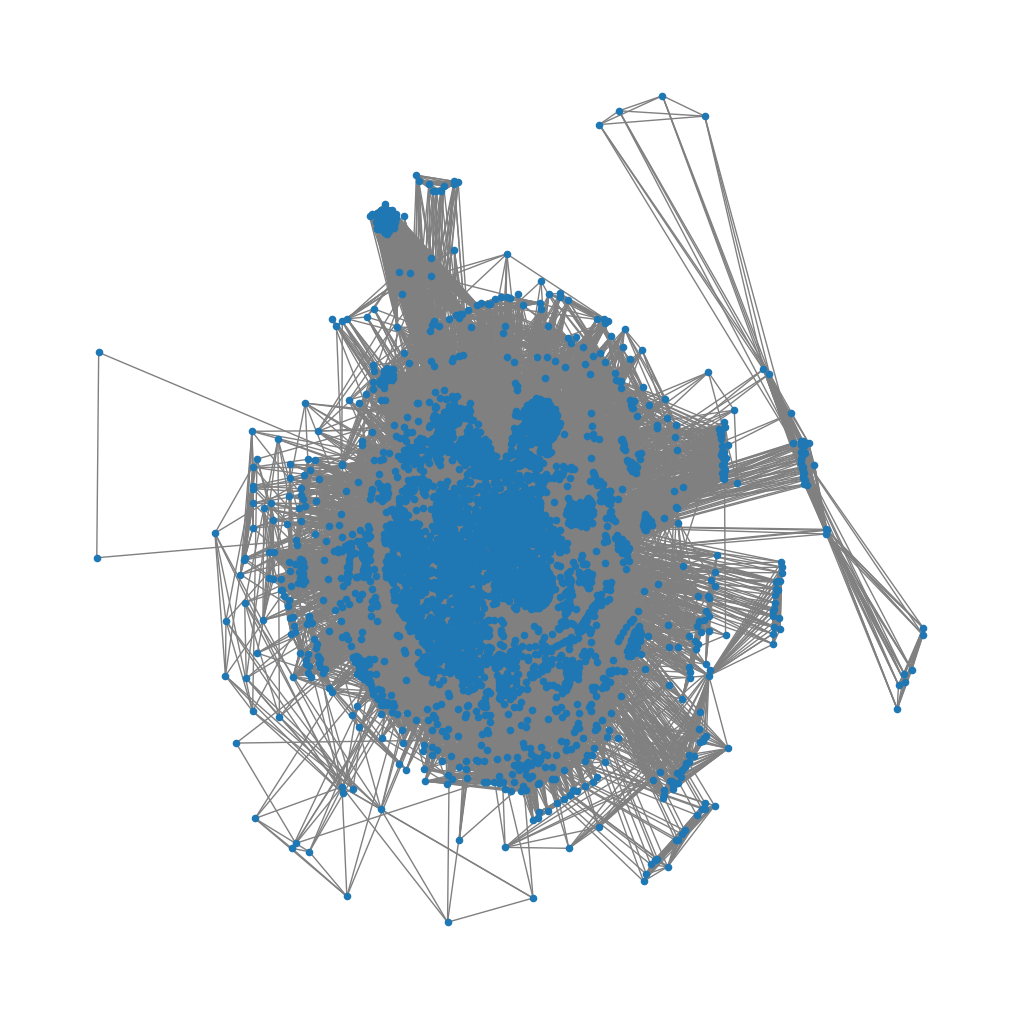

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
nx.draw(G, node_size=20, edge_color="gray")
plt.show()

## Mejoras futuras

- Normalización de entidades (Tejero vs Coronel Tejero)
- Filtrado de ruido OCR
- Grafos dirigidos
- Análisis temporal